In [1]:
import pandas as pd

arquivo = pd.read_csv('Export.csv')

colunas = arquivo.columns

print(colunas)

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Item Code (CPC)', 'Item', 'Year', 'Unit', 'Import', 'Export ',
       'Production', 'Consumption'],
      dtype='object')


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

arquivo_filtrado = arquivo[['Area', 'Year','Item', 'Import','Export ','Production','Consumption']]

ordenados = arquivo_filtrado['Area'].value_counts().sort_values(ascending=False).reset_index()
lista_paises = ordenados['Area'].tolist()[:3] # lista de paises com mais dados no geral

especiarias = arquivo_filtrado['Item'].unique().tolist() # lista de todas as especiarias

# Criando um dicionário para armazenar os dataframes
dicionario_dataframes = {}

for pais in lista_paises:
    for especiaria in especiarias:
        chave = f"{pais}_{especiaria}"
        arquivo_pais = arquivo_filtrado[(arquivo_filtrado['Area'] == pais) & (arquivo_filtrado['Item'] == especiaria)]
        
        # Adicionando o dataframe ao dicionário
        dicionario_dataframes[chave] = arquivo_pais
        
        print(f"Adicionado ao dicionário: {chave} com {len(arquivo_pais)} registros")

Adicionado ao dicionário: China, Hong Kong SAR_Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw com 31 registros
Adicionado ao dicionário: China, Hong Kong SAR_Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw com 31 registros
Adicionado ao dicionário: China, Hong Kong SAR_Chillies and peppers, green (Capsicum spp. and Pimenta spp.) com 31 registros
Adicionado ao dicionário: China, Hong Kong SAR_Cinnamon and cinnamon-tree flowers, raw com 31 registros
Adicionado ao dicionário: China, Hong Kong SAR_Cloves (whole stems), raw com 31 registros
Adicionado ao dicionário: China, Hong Kong SAR_Ginger, raw com 31 registros
Adicionado ao dicionário: China, Hong Kong SAR_Nutmeg, mace, cardamoms, raw com 31 registros
Adicionado ao dicionário: China, Hong Kong SAR_Pepper (Piper spp.), raw com 31 registros
Adicionado ao dicionário: China, Hong Kong SAR_Vanilla, raw com 31 registros
Adicionado ao dicionário: China_Anise, badian, coriander, cumin, caraway, fennel an

In [12]:
# for dataframe in dicionario_dataframes.keys():
#     print(dataframe)

#print(type(list(dicionario_dataframes.keys())))

lista_chaves = list(dicionario_dataframes.keys())

print(dicionario_dataframes[lista_chaves[0]])


                      Area  Year  \
8122  China, Hong Kong SAR  1993   
8123  China, Hong Kong SAR  1994   
8124  China, Hong Kong SAR  1995   
8125  China, Hong Kong SAR  1996   
8126  China, Hong Kong SAR  1997   
8127  China, Hong Kong SAR  1998   
8128  China, Hong Kong SAR  1999   
8129  China, Hong Kong SAR  2000   
8130  China, Hong Kong SAR  2001   
8131  China, Hong Kong SAR  2002   
8132  China, Hong Kong SAR  2003   
8133  China, Hong Kong SAR  2004   
8134  China, Hong Kong SAR  2005   
8135  China, Hong Kong SAR  2006   
8136  China, Hong Kong SAR  2007   
8137  China, Hong Kong SAR  2008   
8138  China, Hong Kong SAR  2009   
8139  China, Hong Kong SAR  2010   
8140  China, Hong Kong SAR  2011   
8141  China, Hong Kong SAR  2012   
8142  China, Hong Kong SAR  2013   
8143  China, Hong Kong SAR  2014   
8144  China, Hong Kong SAR  2015   
8145  China, Hong Kong SAR  2016   
8146  China, Hong Kong SAR  2017   
8147  China, Hong Kong SAR  2018   
8148  China, Hong Kong SAR  

In [4]:
from sklearn.model_selection import train_test_split

# Separa features e target
X = df.drop("target", axis=1)
y = df["target"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



KeyError: 0

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



for chave, dataframe in dicionario_dataframes.items():
    
    print(f"Resultados relacionados a {chave} com previsão de consumo de especiarias:")
    # Separa features e target
    X = dataframe.drop(["Area", "Item", "Consumption"], axis=1)
    y = dataframe["Consumption"]


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    modelos = {
        "Regressão Linear": LinearRegression(),
        "Árvore de Decisão": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(),
        "SVM": SVR(),
        "Rede Neural (MLP)": MLPRegressor(max_iter=1000)
    }

    for nome, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

        print(f"🔹 {nome}")
        print("MAE:", mean_absolute_error(y_test, y_pred))
        print("MSE:", mean_squared_error(y_test, y_pred))
        print("R²:", r2_score(y_test, y_pred))
        print("-" * 40)


Resultados relacionados a China, Hong Kong SAR_Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw com previsão de consumo de especiarias:
🔹 Regressão Linear
MAE: 4.628678392951509e-13
MSE: 2.4695403332358807e-25
R²: 1.0
----------------------------------------
🔹 Árvore de Decisão
MAE: 83.65714285714284
MSE: 11755.820314285713
R²: 0.5904918331088179
----------------------------------------
🔹 Random Forest
MAE: 87.1066714285713
MSE: 15671.75011181856
R²: 0.4540823618689822
----------------------------------------
🔹 SVM
MAE: 127.54264116289833
MSE: 30489.094865016472
R²: -0.06207248958813927
----------------------------------------


/home/mateus/Documentos/IA/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


🔹 Rede Neural (MLP)
MAE: 134.74783410918351
MSE: 42808.72923138756
R²: -0.49122083919429493
----------------------------------------
Resultados relacionados a China, Hong Kong SAR_Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw com previsão de consumo de especiarias:
🔹 Regressão Linear
MAE: 1.2992781453898975e-12
MSE: 2.186120190318716e-24
R²: 1.0
----------------------------------------
🔹 Árvore de Decisão
MAE: 214.10857142857142
MSE: 92129.19660000001
R²: 0.3258827558160605
----------------------------------------
🔹 Random Forest
MAE: 166.90451428571424
MSE: 39355.93052129997
R²: 0.7120292762293194
----------------------------------------
🔹 SVM
MAE: 356.1008143987803
MSE: 148167.54828988962
R²: -0.08415467644131347
----------------------------------------


/home/mateus/Documentos/IA/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


🔹 Rede Neural (MLP)
MAE: 638.0836327903204
MSE: 518435.11431380926
R²: -2.7934342580537677
----------------------------------------
Resultados relacionados a China, Hong Kong SAR_Chillies and peppers, green (Capsicum spp. and Pimenta spp.) com previsão de consumo de especiarias:
🔹 Regressão Linear
MAE: 3.2481953634747435e-14
MSE: 7.385541183509175e-27
R²: 1.0
----------------------------------------
🔹 Árvore de Decisão
MAE: 273.3014285714286
MSE: 243968.5564714286
R²: 0.5147345438229234
----------------------------------------
🔹 Random Forest
MAE: 337.1890142857145
MSE: 375205.5670023157
R²: 0.25369767618852823
----------------------------------------
🔹 SVM
MAE: 562.813753565118
MSE: 536262.4784621213
R²: -0.06665244081176014
----------------------------------------


...

/home/mateus/Documentos/IA/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


🔹 Rede Neural (MLP)
MAE: 402.16757017060314
MSE: 201455.22439324387
R²: -0.7072472659130908
----------------------------------------
Resultados relacionados a Canada_Pepper (Piper spp.), raw com previsão de consumo de especiarias:
🔹 Regressão Linear
MAE: 1.2992781453898974e-13
MSE: 1.181686589361468e-25
R²: 1.0
----------------------------------------
🔹 Árvore de Decisão
MAE: 213.51142857142855
MSE: 72750.5901142858
R²: 0.908352160777818
----------------------------------------
🔹 Random Forest
MAE: 116.37677142857241
MSE: 27870.157458565733
R²: 0.964890460601804
----------------------------------------
🔹 SVM
MAE: 707.2267134647146
MSE: 982500.7969904493
R²: -0.23770920533831852
----------------------------------------


/home/mateus/Documentos/IA/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


🔹 Rede Neural (MLP)
MAE: 5432.05838378839
MSE: 30025425.0642129
R²: -36.82464615805643
----------------------------------------
Resultados relacionados a Canada_Vanilla, raw com previsão de consumo de especiarias:
🔹 Regressão Linear
MAE: 1.806808670932826e-13
MSE: 4.618848216718043e-26
R²: 1.0
----------------------------------------
🔹 Árvore de Decisão
MAE: 42.66142857142857
MSE: 2511.4881857142855
R²: 0.8527175851885748
----------------------------------------
🔹 Random Forest
MAE: 39.55634285714284
MSE: 2492.8786401971415
R²: 0.8538089137553976
----------------------------------------
🔹 SVM
MAE: 110.06607581026637
MSE: 19995.887923227827
R²: -0.17262851419466996
----------------------------------------
🔹 Rede Neural (MLP)
MAE: 79.77885027471659
MSE: 7242.051740575206
R²: 0.5753008616133125
----------------------------------------


/home/mateus/Documentos/IA/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



# arquivo_filtrado = arquivo[['Area', 'Year','Item', 'Import','Export ','Production','Consumption']]
arquivo_filtrado.columns = arquivo_filtrado.columns.str.strip()

X = arquivo_filtrado[["Year", "Area", "Item"]]
X = pd.get_dummies(X, columns=["Area", "Item"])
y = arquivo_filtrado[["Production", "Import", "Export"]]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

modelos = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVM": SVR(),
    "Rede Neural (MLP)": MLPRegressor(max_iter=1000)
}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    print(f"🔹 {nome}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))
    print("-" * 40)

🔹 Regressão Linear
MAE: 29191.498416034792
MSE: 60837689465.942024
R²: 0.13726750101737994
----------------------------------------
🔹 Árvore de Decisão
MAE: 1022.6441673101658
MSE: 216480869.7020876
R²: 0.9884262462676686
----------------------------------------
🔹 Random Forest
MAE: 853.8958762493103
MSE: 172731004.36993286
R²: 0.9920747131286394
----------------------------------------


ValueError: y should be a 1d array, got an array of shape (36256, 3) instead.

In [20]:
MLPRegressor(max_iter=1000).fit(X_train, y_train)
y_pred = MLPRegressor(max_iter=1000).predict(X_test)

print(f"🔹 {nome}")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
print("-" * 40)

/home/mateus/Documentos/IA/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


NotFittedError: This MLPRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
0,Afghanistan,2014,"Anise, badian, coriander, cumin, caraway, fenn...",283.85,21099.0,21500.00,False,False,True
1,Afghanistan,2015,"Anise, badian, coriander, cumin, caraway, fenn...",1000.16,17340.0,18000.00,False,False,False
2,Afghanistan,2016,"Anise, badian, coriander, cumin, caraway, fenn...",814.88,8353.0,17333.33,False,False,False
3,Afghanistan,2017,"Anise, badian, coriander, cumin, caraway, fenn...",3.67,8500.0,18234.12,False,False,False
4,Afghanistan,2018,"Anise, badian, coriander, cumin, caraway, fenn...",112.30,9456.0,17855.82,False,False,False
...,...,...,...,...,...,...,...,...,...
45078,Zimbabwe,2019,"Anise, badian, coriander, cumin, caraway, fenn...",16.98,0.0,82.17,False,False,False
45079,Zimbabwe,2020,"Anise, badian, coriander, cumin, caraway, fenn...",20.96,0.0,84.18,False,False,False
45080,Zimbabwe,2021,"Anise, badian, coriander, cumin, caraway, fenn...",43.78,0.0,84.20,False,False,False
45081,Zimbabwe,2022,"Anise, badian, coriander, cumin, caraway, fenn...",35.80,0.0,83.52,False,False,False


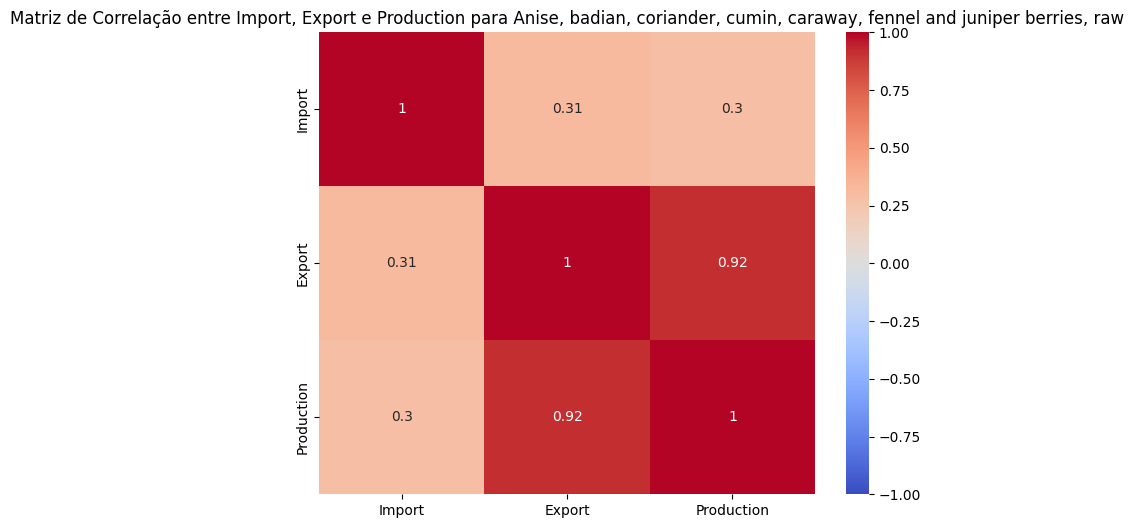

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
10,Afghanistan,2014,"Chillies and peppers, dry (Capsicum spp., Pime...",4.08,11.01,0.00,False,False,False
11,Afghanistan,2015,"Chillies and peppers, dry (Capsicum spp., Pime...",4.66,0.00,0.00,False,False,False
12,Afghanistan,2016,"Chillies and peppers, dry (Capsicum spp., Pime...",5.43,2.00,0.00,False,False,False
13,Afghanistan,2018,"Chillies and peppers, dry (Capsicum spp., Pime...",41.93,1.91,0.00,False,False,False
14,Afghanistan,2020,"Chillies and peppers, dry (Capsicum spp., Pime...",3471.77,288.99,0.00,True,False,False
...,...,...,...,...,...,...,...,...,...
45109,Zimbabwe,2019,"Chillies and peppers, dry (Capsicum spp., Pime...",3.26,836.69,251.11,False,False,False
45110,Zimbabwe,2020,"Chillies and peppers, dry (Capsicum spp., Pime...",1.43,1465.55,283.88,False,False,False
45111,Zimbabwe,2021,"Chillies and peppers, dry (Capsicum spp., Pime...",2.34,739.18,286.78,False,False,False
45112,Zimbabwe,2022,"Chillies and peppers, dry (Capsicum spp., Pime...",8.60,974.10,334.66,False,False,False


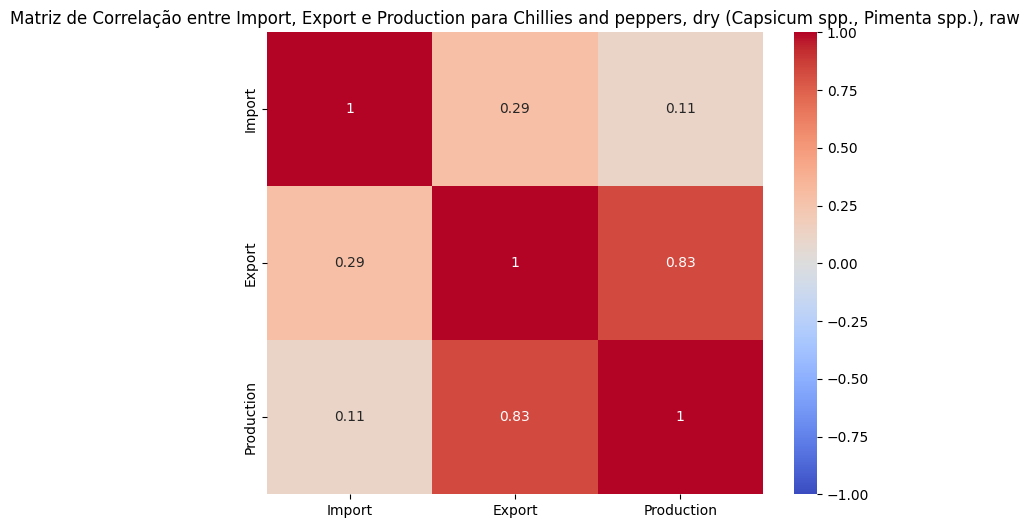

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
18,Afghanistan,2014,"Chillies and peppers, green (Capsicum spp. and...",1425.09,1.52,0.00,False,False,False
19,Afghanistan,2015,"Chillies and peppers, green (Capsicum spp. and...",5.23,0.13,0.00,False,False,False
20,Afghanistan,2016,"Chillies and peppers, green (Capsicum spp. and...",4439.92,174.43,0.00,False,False,False
21,Afghanistan,2018,"Chillies and peppers, green (Capsicum spp. and...",3382.84,36.67,0.00,False,False,False
22,Afghanistan,2020,"Chillies and peppers, green (Capsicum spp. and...",20209.43,436.50,0.00,False,False,False
...,...,...,...,...,...,...,...,...,...
45135,Zimbabwe,2015,"Chillies and peppers, green (Capsicum spp. and...",53.46,6.83,13390.32,False,False,False
45136,Zimbabwe,2016,"Chillies and peppers, green (Capsicum spp. and...",13.54,29.74,15020.95,False,False,False
45137,Zimbabwe,2017,"Chillies and peppers, green (Capsicum spp. and...",0.47,182.17,16713.80,False,False,False
45138,Zimbabwe,2018,"Chillies and peppers, green (Capsicum spp. and...",0.32,8.88,18458.55,False,False,False


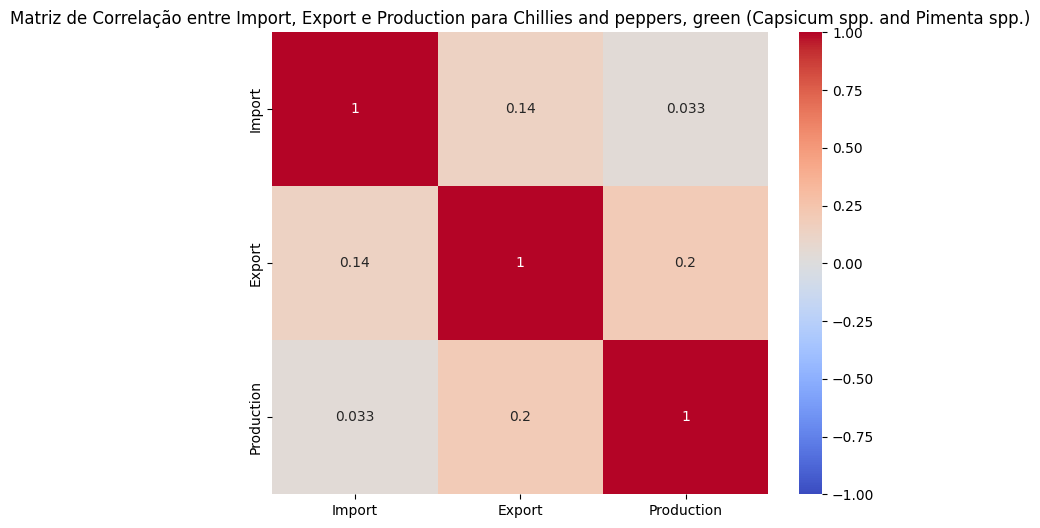

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
26,Afghanistan,2014,"Cinnamon and cinnamon-tree flowers, raw",6.04,0.00,0.0,False,False,False
27,Afghanistan,2015,"Cinnamon and cinnamon-tree flowers, raw",4.92,0.90,0.0,False,False,False
28,Afghanistan,2016,"Cinnamon and cinnamon-tree flowers, raw",9.01,1.56,0.0,False,False,False
29,Afghanistan,2018,"Cinnamon and cinnamon-tree flowers, raw",43.78,0.00,0.0,False,False,False
30,Afghanistan,2019,"Cinnamon and cinnamon-tree flowers, raw",437.14,0.00,0.0,True,False,False
...,...,...,...,...,...,...,...,...,...
45166,Zimbabwe,2019,"Cinnamon and cinnamon-tree flowers, raw",4.08,0.00,0.0,False,False,False
45167,Zimbabwe,2020,"Cinnamon and cinnamon-tree flowers, raw",3.46,0.00,0.0,False,False,False
45168,Zimbabwe,2021,"Cinnamon and cinnamon-tree flowers, raw",9.27,0.00,0.0,False,False,False
45169,Zimbabwe,2022,"Cinnamon and cinnamon-tree flowers, raw",7.93,0.00,0.0,False,False,False


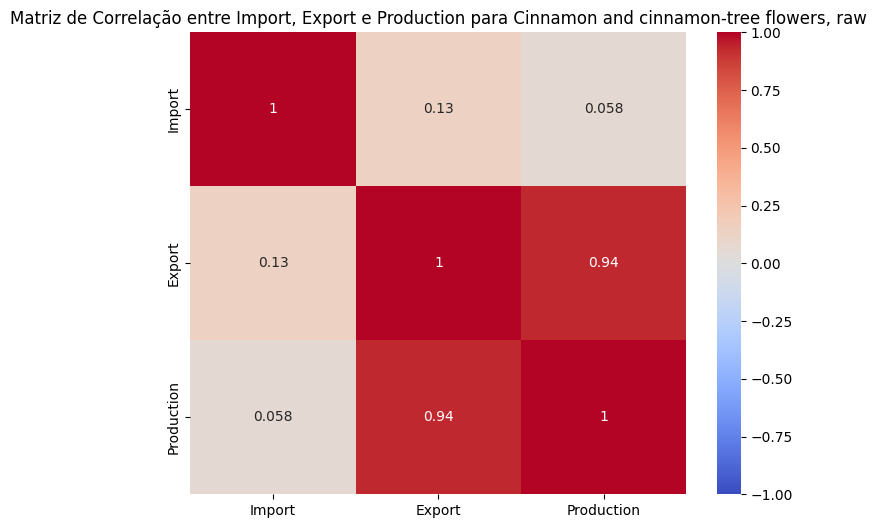

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
35,Afghanistan,2014,"Cloves (whole stems), raw",0.08,0.00,0.0,False,False,False
36,Afghanistan,2015,"Cloves (whole stems), raw",2.72,0.00,0.0,False,False,False
37,Afghanistan,2016,"Cloves (whole stems), raw",0.16,0.00,0.0,False,False,False
38,Afghanistan,2018,"Cloves (whole stems), raw",7.00,0.02,0.0,False,False,False
39,Afghanistan,2019,"Cloves (whole stems), raw",45.76,0.00,0.0,False,False,False
...,...,...,...,...,...,...,...,...,...
45197,Zimbabwe,2019,"Cloves (whole stems), raw",1.25,0.00,0.0,False,False,False
45198,Zimbabwe,2020,"Cloves (whole stems), raw",2.74,0.00,0.0,False,False,False
45199,Zimbabwe,2021,"Cloves (whole stems), raw",3.62,0.00,0.0,False,False,False
45200,Zimbabwe,2022,"Cloves (whole stems), raw",6.62,0.00,0.0,False,False,False


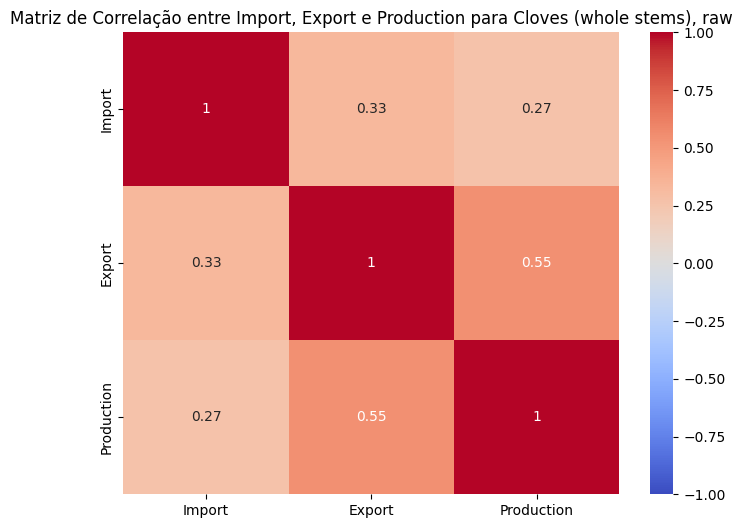

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
44,Afghanistan,2014,"Ginger, raw",0.37,0.00,0.0,False,False,False
45,Afghanistan,2015,"Ginger, raw",17.18,0.00,0.0,False,False,False
46,Afghanistan,2016,"Ginger, raw",7.07,0.01,0.0,False,False,False
47,Afghanistan,2018,"Ginger, raw",13.55,1.39,0.0,False,False,False
48,Afghanistan,2019,"Ginger, raw",93.40,0.02,0.0,False,False,False
...,...,...,...,...,...,...,...,...,...
45228,Zimbabwe,2019,"Ginger, raw",8.43,0.00,0.0,False,False,False
45229,Zimbabwe,2020,"Ginger, raw",13.37,0.00,0.0,False,False,False
45230,Zimbabwe,2021,"Ginger, raw",32.93,0.00,0.0,True,False,False
45231,Zimbabwe,2022,"Ginger, raw",5.15,0.00,0.0,False,False,False


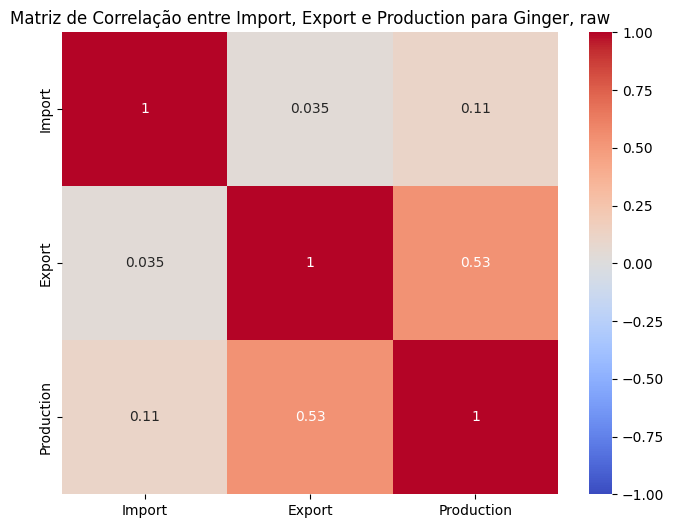

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
53,Afghanistan,2014,"Nutmeg, mace, cardamoms, raw",87.94,0.00,0.0,False,False,False
54,Afghanistan,2015,"Nutmeg, mace, cardamoms, raw",106.56,2.25,0.0,False,False,False
55,Afghanistan,2016,"Nutmeg, mace, cardamoms, raw",96.31,5.88,0.0,False,True,False
56,Afghanistan,2018,"Nutmeg, mace, cardamoms, raw",30.97,0.00,0.0,False,False,False
57,Afghanistan,2019,"Nutmeg, mace, cardamoms, raw",89.84,0.00,0.0,False,False,False
...,...,...,...,...,...,...,...,...,...
45259,Zimbabwe,2019,"Nutmeg, mace, cardamoms, raw",0.87,0.00,0.0,False,False,False
45260,Zimbabwe,2020,"Nutmeg, mace, cardamoms, raw",0.27,0.00,0.0,False,False,False
45261,Zimbabwe,2021,"Nutmeg, mace, cardamoms, raw",1.46,0.00,0.0,False,False,False
45262,Zimbabwe,2022,"Nutmeg, mace, cardamoms, raw",0.58,0.00,0.0,False,False,False


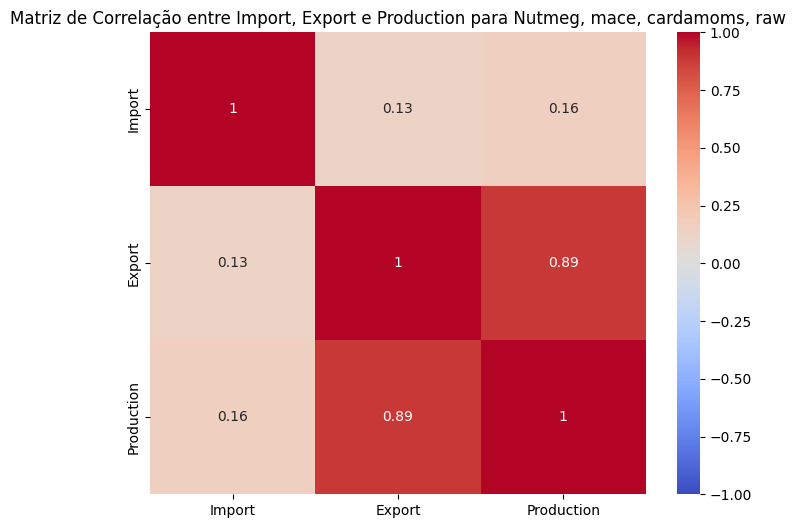

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
62,Afghanistan,1993,"Pepper (Piper spp.), raw",30.00,0.00,0.00,False,False,False
63,Afghanistan,1994,"Pepper (Piper spp.), raw",90.00,0.00,0.00,False,False,False
64,Afghanistan,1995,"Pepper (Piper spp.), raw",120.00,0.00,0.00,False,False,False
65,Afghanistan,1996,"Pepper (Piper spp.), raw",0.00,0.00,0.00,False,False,False
66,Afghanistan,1997,"Pepper (Piper spp.), raw",0.00,0.00,0.00,False,False,False
...,...,...,...,...,...,...,...,...,...
45290,Zimbabwe,2019,"Pepper (Piper spp.), raw",10.32,319.97,23584.00,False,False,False
45291,Zimbabwe,2020,"Pepper (Piper spp.), raw",12.61,418.68,29152.00,False,False,False
45292,Zimbabwe,2021,"Pepper (Piper spp.), raw",34.66,443.94,22468.44,False,False,False
45293,Zimbabwe,2022,"Pepper (Piper spp.), raw",31.65,692.61,16980.00,False,False,True


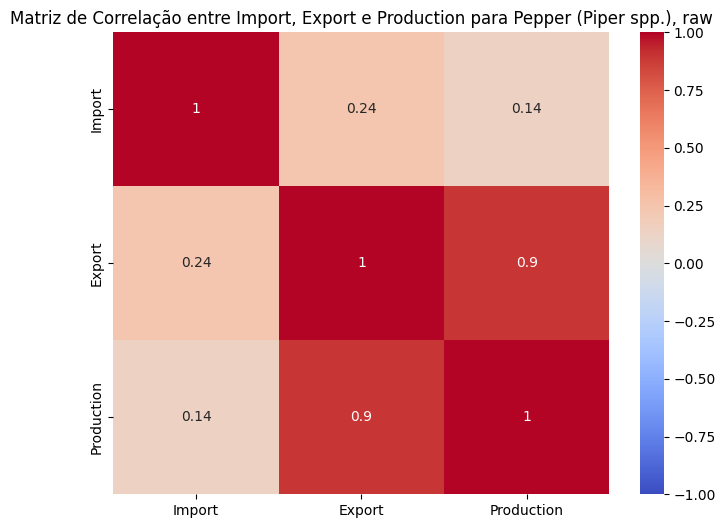

,Area,Year,Item,Import,Export,Production,is_outlier_Import,is_outlier_Export,is_outlier_Production
92,Afghanistan,2014,"Vanilla, raw",6.68,0.0,0.00,False,False,False
93,Afghanistan,2016,"Vanilla, raw",0.18,0.0,0.00,False,False,False
94,Afghanistan,2018,"Vanilla, raw",0.20,0.0,0.00,False,False,False
95,Afghanistan,2019,"Vanilla, raw",27.04,0.0,0.00,True,False,False
96,Afghanistan,2020,"Vanilla, raw",1.71,0.0,0.00,False,False,False
...,...,...,...,...,...,...,...,...,...
45316,Zimbabwe,2014,"Vanilla, raw",0.04,0.0,10.09,False,False,False
45317,Zimbabwe,2015,"Vanilla, raw",0.10,0.0,10.11,False,False,False
45318,Zimbabwe,2016,"Vanilla, raw",0.01,0.0,9.73,False,False,False
45319,Zimbabwe,2019,"Vanilla, raw",0.02,0.0,9.88,False,False,False


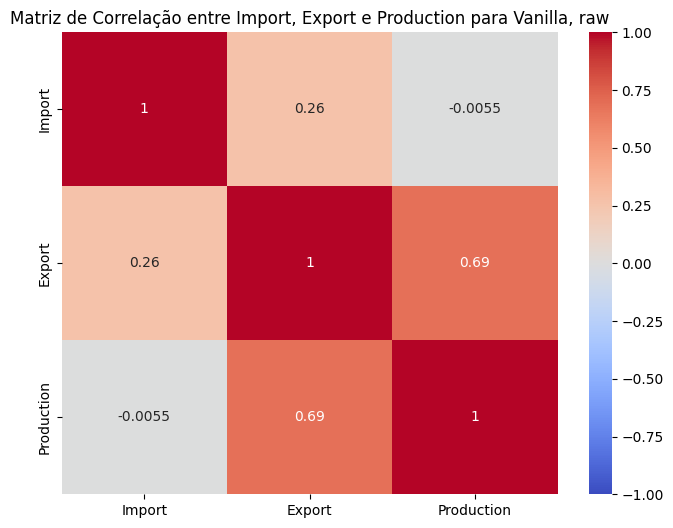

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dados = pd.read_csv('arquivo_filtrado.csv')

lista_especiarias = dados['Item'].unique().tolist()

for especiaria in lista_especiarias:
    dados_especiaria = dados[dados['Item'] == especiaria]
    display(dados_especiaria)
    dados_especiaria.to_csv(f'dados_{especiaria}.csv', index=False)

    colunas_numericas = ['Import', 'Export', 'Production']
    dados_corr = dados_especiaria[colunas_numericas]

    # Verificando correlações somente entre essas três colunas
    plt.figure(figsize=(8, 6))
    sns.heatmap(dados_corr.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f'Matriz de Correlação entre Import, Export e Production para {especiaria}')
    plt.show()


